# 1. Imports

In [ ]:
from collections.abc import Sequence
from typing import Literal, cast

import matplotlib.pylab as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown
from matplotlib.axes import Axes
from matplotlib.container import BarContainer
from pandas import DataFrame

plt.style.use("dark_background")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["figure.constrained_layout.use"] = True

FRAUD_LEGEND = ["Non fraudulent", "Fraudulent"]
type NORMALIZE_TYPE = Literal["index", "columns"]

In [2]:
def build_graph(
    ax: Axes,
    title: str,
    y_label: str | None = None,
    legend_labels: Sequence[str] | None = None,
) -> None:
    """
    Configure the appearance of a matplotlib chart.

    Set the chart title, optionally updates the y-axis label, and
    customize the legend by removing its title and replacing the legend
    labels.

    Args:
        ax: Matplotlib axes containing the plot.
        title: Chart title.
        y_label: Label for the y-axis. If None, the current label is
            left unchanged.
        legend_labels: Labels used to replace the existing legend labels.
            If None, the legend labels are not modified.
    """

    ax.set_title(title)

    if y_label:
        ax.set_ylabel(y_label)

    legend = ax.get_legend()

    if legend is None:
        return

    legend.set_title("")

    if legend_labels:
        for text, label in zip(legend.get_texts(), legend_labels):
            text.set_text(label)


def analyze_categorical(
    df: DataFrame,
    col: str,
    title: str,
    y_label: str | None,
    legend_labels: Sequence[str] | None,
    index_column_name: str,
    table_1_name: str,
    table_2_name: str,
    table_3_name: str,
    round_format: str = "%.02f%%",
    is_bar_label: bool = True,
) -> None:
    """
    Analyze and visualize a categorical feature.

    Create a count plot showing the percentage distribution of a
    categorical feature by fraud status.
    Also display summary tables containing fraud counts and normalized
    contingency tables.

        Args:
        df: Input dataframe.
        col: Name of the categorical column to analyze.
        title: Plot title.
        y_label: Label for the y-axis.
        legend_labels: Labels used to replace the default legend labels.
        index_column_name: Name of the count column in the first summary table.
        table_1_name: Heading displayed above the fraud-count table.
        table_2_name: Heading displayed above the column-normalized
        contingency table.
        table_3_name: Heading displayed above the row-normalized
        contingency table.
        round_format: Format string used for bar labels.
        is_bar_label: Whether to display values on top of the bars.
    """
    ax = sns.countplot(
        data=df,
        x=col,
        stat="percent",
        hue="is_fraud",
        order=df[col].value_counts().index,
    )
    build_graph(
        ax,
        title,
        y_label,
        legend_labels,
    )
    if is_bar_label:
        for container in ax.containers:
            ax.bar_label(cast(BarContainer, container), fmt=round_format)

    plt.show()

    # Number of merchant category by fraud count
    table_1 = (
        df.astype({"is_fraud": "int"})
        .groupby(col, observed=True)["is_fraud"]
        .sum()
        .value_counts()
        .sort_index()
        .rename_axis("number_of_frauds")
        .reset_index(name=index_column_name)
    )

    display(
        Markdown(f"## {table_1_name}"),
        table_1,
    )

    map_normalize_type_title: dict[NORMALIZE_TYPE, str] = {
        "columns": table_2_name,
        "index": table_3_name,
    }

    for normalize_type, table_title in map_normalize_type_title.items():
        display(
            Markdown(f"## {table_title}"),
            pd.crosstab(
                df[col],
                df["is_fraud"],
                margins=True,
                normalize=normalize_type,
            ),
        )

In [3]:
df = pd.read_csv("./downloads/fraud_enriched.csv")

# 2. Data understanding

In [4]:
df.shape

(100000, 42)

In [5]:
df.head()

,transaction_id,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,event_ts,card_id,merchant_id,merchant_category_code,merchant_country,currency,device_type,entry_mode,channel,is_international
0,4c8578a1-c414-4bce-823d-76ecc7dc99e6,61615,1.221934,-1.234972,0.404137,-0.087271,0.067945,-0.628529,-0.773179,1.246143,...,2025-06-29T09:09:58Z,C0008699,M001819,5300,NL,EUR,desktop,contactless,ecommerce,True
1,5d09e21c-3c4b-4fbb-a043-00683483eb82,49689,1.426940,-0.946178,-0.494617,0.316493,-0.157020,-0.496480,-0.228682,-0.471507,...,2025-06-29T05:51:12Z,C0017905,M000183,5999,PT,EUR,mobile,contactless,pos,True
2,7db564cd-6fa0-497b-b24b-c0d7b131b65d,10742,0.869426,1.182445,0.872349,0.013707,0.042192,-1.139108,-0.973890,-1.222907,...,2025-06-28T19:02:05Z,C0005316,M001073,5732,IT,EUR,mobile,chip,pos,True
3,699d3edb-365a-4116-ab94-6a0795dd61a9,53459,0.320630,-1.220708,1.264100,0.694466,0.837338,1.238178,-0.801350,0.383556,...,2025-06-29T06:54:02Z,C0001373,M003532,5411,PT,EUR,desktop,contactless,pos,True
4,68da6b3d-ff29-400c-bcb9-aeedffd772a3,66455,-1.047278,1.181596,-0.539802,0.207493,0.597572,0.586189,1.563855,0.356156,...,2025-06-29T10:30:38Z,C0012578,M004198,4812,IT,EUR,mobile,chip,pos,True


In [6]:
df.columns

Index(['transaction_id', 'Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7',
       'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17',
       'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27',
       'V28', 'Amount', 'Class', 'event_ts', 'card_id', 'merchant_id',
       'merchant_category_code', 'merchant_country', 'currency', 'device_type',
       'entry_mode', 'channel', 'is_international'],
      dtype='object')

In [7]:
df.dtypes

transaction_id             object
Time                        int64
V1                        float64
V2                        float64
V3                        float64
V4                        float64
V5                        float64
V6                        float64
V7                        float64
V8                        float64
V9                        float64
V10                       float64
V11                       float64
V12                       float64
V13                       float64
V14                       float64
V15                       float64
V16                       float64
V17                       float64
V18                       float64
V19                       float64
V20                       float64
V21                       float64
V22                       float64
V23                       float64
V24                       float64
V25                       float64
V26                       float64
V27                       float64
V28           

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,100000.0,86557.121760,49842.557102,0.000000,43739.750000,86634.500000,129669.250000,172799.000000
V1,100000.0,-0.002027,1.000140,-4.311778,-0.678612,-0.003357,0.676200,4.498862
V2,100000.0,-0.002372,0.998589,-4.160471,-0.672828,-0.005516,0.669523,4.064655
V3,100000.0,-0.003377,0.997278,-4.368998,-0.676302,-0.004299,0.667963,4.082286
V4,100000.0,0.004456,0.999513,-3.971677,-0.668626,0.002735,0.679012,5.025995
V5,100000.0,0.002037,0.999340,-4.440154,-0.672817,-0.002231,0.673642,4.586117
V6,100000.0,0.001726,0.997328,-4.385001,-0.675052,0.002322,0.676651,4.492373
V7,100000.0,0.004513,0.998488,-4.542178,-0.670581,0.007123,0.682040,4.564227
V8,100000.0,0.002600,0.999435,-4.515347,-0.668353,0.000130,0.675260,4.569566
V9,100000.0,-0.003376,1.000710,-4.210185,-0.679904,-0.003511,0.673760,4.135356


# 3. Data preparation

In [9]:
df.head()

,transaction_id,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,event_ts,card_id,merchant_id,merchant_category_code,merchant_country,currency,device_type,entry_mode,channel,is_international
0,4c8578a1-c414-4bce-823d-76ecc7dc99e6,61615,1.221934,-1.234972,0.404137,-0.087271,0.067945,-0.628529,-0.773179,1.246143,...,2025-06-29T09:09:58Z,C0008699,M001819,5300,NL,EUR,desktop,contactless,ecommerce,True
1,5d09e21c-3c4b-4fbb-a043-00683483eb82,49689,1.426940,-0.946178,-0.494617,0.316493,-0.157020,-0.496480,-0.228682,-0.471507,...,2025-06-29T05:51:12Z,C0017905,M000183,5999,PT,EUR,mobile,contactless,pos,True
2,7db564cd-6fa0-497b-b24b-c0d7b131b65d,10742,0.869426,1.182445,0.872349,0.013707,0.042192,-1.139108,-0.973890,-1.222907,...,2025-06-28T19:02:05Z,C0005316,M001073,5732,IT,EUR,mobile,chip,pos,True
3,699d3edb-365a-4116-ab94-6a0795dd61a9,53459,0.320630,-1.220708,1.264100,0.694466,0.837338,1.238178,-0.801350,0.383556,...,2025-06-29T06:54:02Z,C0001373,M003532,5411,PT,EUR,desktop,contactless,pos,True
4,68da6b3d-ff29-400c-bcb9-aeedffd772a3,66455,-1.047278,1.181596,-0.539802,0.207493,0.597572,0.586189,1.563855,0.356156,...,2025-06-29T10:30:38Z,C0012578,M004198,4812,IT,EUR,mobile,chip,pos,True


In [10]:
df["event_ts"] = pd.to_datetime(df["event_ts"])

In [11]:
date_parts = {
    "day_event": "day",
    "weekday_event": "weekday",
    "month_event": "month",
    "year_event": "year",
    "hour_event": "hour",
}

dt = df["event_ts"].dt

for column, attribute in date_parts.items():
    df[column] = getattr(dt, attribute)

In [12]:
df.dtypes

transaction_id                         object
Time                                    int64
V1                                    float64
V2                                    float64
V3                                    float64
V4                                    float64
V5                                    float64
V6                                    float64
V7                                    float64
V8                                    float64
V9                                    float64
V10                                   float64
V11                                   float64
V12                                   float64
V13                                   float64
V14                                   float64
V15                                   float64
V16                                   float64
V17                                   float64
V18                                   float64
V19                                   float64
V20                               

In [13]:
df.columns = df.columns.str.lower()
df = df.rename(columns={"class": "is_fraud"})

In [14]:
type_mapping = {
    "merchant_category_code": "category",
    "merchant_country": "category",
    "currency": "category",
    "device_type": "category",
    "entry_mode": "category",
    "channel": "category",
    "is_international": "category",
    "is_fraud": "category",
}
df = df.astype(type_mapping)

In [15]:
df.describe()

,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v25,v26,v27,v28,amount,day_event,weekday_event,month_event,year_event,hour_event
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.0,100000.000000
mean,86557.121760,-0.002027,-0.002372,-0.003377,0.004456,0.002037,0.001726,0.004513,0.002600,-0.003376,...,0.002234,-0.001480,0.001295,0.001723,30.173969,29.170380,3.822650,6.0,2025.0,11.504480
std,49842.557102,1.000140,0.998589,0.997278,0.999513,0.999340,0.997328,0.998488,0.999435,1.000710,...,0.992198,1.000868,0.993636,1.002357,34.410164,0.686568,2.738297,0.0,0.0,6.908676
min,0.000000,-4.311778,-4.160471,-4.368998,-3.971677,-4.440154,-4.385001,-4.542178,-4.515347,-4.210185,...,-3.984893,-4.292813,-4.582791,-4.863267,0.280000,28.000000,0.000000,6.0,2025.0,0.000000
25%,43739.750000,-0.678612,-0.672828,-0.676302,-0.668626,-0.672817,-0.675052,-0.670581,-0.668353,-0.679904,...,-0.667145,-0.676939,-0.666677,-0.676402,10.930000,29.000000,0.000000,6.0,2025.0,6.000000
50%,86634.500000,-0.003357,-0.005516,-0.004299,0.002735,-0.002231,0.002322,0.007123,0.000130,-0.003511,...,0.002969,-0.003178,0.000172,0.001636,20.100000,29.000000,5.000000,6.0,2025.0,12.000000
75%,129669.250000,0.676200,0.669523,0.667963,0.679012,0.673642,0.676651,0.682040,0.675260,0.673760,...,0.676197,0.668772,0.670467,0.673283,36.970000,30.000000,6.000000,6.0,2025.0,17.000000
max,172799.000000,4.498862,4.064655,4.082286,5.025995,4.586117,4.492373,4.564227,4.569566,4.135356,...,4.463650,4.827989,3.939563,4.230806,2325.340000,30.000000,6.000000,6.0,2025.0,23.000000


In [16]:
df.describe(include=["category"])

,is_fraud,merchant_category_code,merchant_country,currency,device_type,entry_mode,channel,is_international
count,100000,100000,100000,100000,100000,100000,100000,100000
unique,2,10,30,3,3,4,2,2
top,0,5812,BE,EUR,mobile,chip,pos,True
freq,99703,24951,5206,87816,55038,47983,60039,95123


In [17]:
df.isna().sum()

transaction_id            0
time                      0
v1                        0
v2                        0
v3                        0
v4                        0
v5                        0
v6                        0
v7                        0
v8                        0
v9                        0
v10                       0
v11                       0
v12                       0
v13                       0
v14                       0
v15                       0
v16                       0
v17                       0
v18                       0
v19                       0
v20                       0
v21                       0
v22                       0
v23                       0
v24                       0
v25                       0
v26                       0
v27                       0
v28                       0
amount                    0
is_fraud                  0
event_ts                  0
card_id                   0
merchant_id               0
merchant_category_co

In [18]:
display(df.loc[df.duplicated()])

columns_subsets = [
    ["transaction_id"],
    df.columns.to_list()[1:],  # All but transation_id
    df.columns.to_list()[2:30],  # Only starting v columns
    df.columns.to_list()[30:],  # All but transaction_id, time and starting v columns
]
for s in columns_subsets:
    if df.loc[df.duplicated(subset=s)].empty is True:
        print("Subset has no duplicated values")
    else:
        print(f"Check {s} subset")

,transaction_id,time,v1,v2,v3,v4,v5,v6,v7,v8,...,currency,device_type,entry_mode,channel,is_international,day_event,weekday_event,month_event,year_event,hour_event


Subset has no duplicated values
Subset has no duplicated values
Subset has no duplicated values
Subset has no duplicated values


In [19]:
df.dtypes
display(df.head(5))

,transaction_id,time,v1,v2,v3,v4,v5,v6,v7,v8,...,currency,device_type,entry_mode,channel,is_international,day_event,weekday_event,month_event,year_event,hour_event
0,4c8578a1-c414-4bce-823d-76ecc7dc99e6,61615,1.221934,-1.234972,0.404137,-0.087271,0.067945,-0.628529,-0.773179,1.246143,...,EUR,desktop,contactless,ecommerce,True,29,6,6,2025,9
1,5d09e21c-3c4b-4fbb-a043-00683483eb82,49689,1.426940,-0.946178,-0.494617,0.316493,-0.157020,-0.496480,-0.228682,-0.471507,...,EUR,mobile,contactless,pos,True,29,6,6,2025,5
2,7db564cd-6fa0-497b-b24b-c0d7b131b65d,10742,0.869426,1.182445,0.872349,0.013707,0.042192,-1.139108,-0.973890,-1.222907,...,EUR,mobile,chip,pos,True,28,5,6,2025,19
3,699d3edb-365a-4116-ab94-6a0795dd61a9,53459,0.320630,-1.220708,1.264100,0.694466,0.837338,1.238178,-0.801350,0.383556,...,EUR,desktop,contactless,pos,True,29,6,6,2025,6
4,68da6b3d-ff29-400c-bcb9-aeedffd772a3,66455,-1.047278,1.181596,-0.539802,0.207493,0.597572,0.586189,1.563855,0.356156,...,EUR,mobile,chip,pos,True,29,6,6,2025,10


# 4. Feature understanding

## Univariate analysis

### Is_fraud

In [ ]:
ax = sns.countplot(data=df, x="is_fraud", stat="percent", legend=True)

build_graph(
    ax,
    "Distribution of fraudulent and non fraudulent transactions",
    "Share of all transactions (%)",
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Not fraud", "Fraud"])


for container in ax.containers:
    ax.bar_label(cast(BarContainer, container), fmt="%.2f%%")

plt.show()

### time

In [ ]:
col_to_plot = "time"

ax = sns.histplot(
    df,
    x=col_to_plot,
    stat="density",
    hue="is_fraud",
    hue_order=[0, 1],
    kde=True,
    bins=15,
    common_norm=False,
    legend=True,
)

build_graph(
    ax,
    f"Distribution of fraudulent and non fraudulent {col_to_plot}",
    None,
    FRAUD_LEGEND,
)

plt.show()

### V columns

In [ ]:
# Choose a range or a list of numbers between 1 and 28
# in order to not display all plots.

cols = range(1, 4)

for col in cols:
    ax = sns.histplot(
        df,
        x=f"v{col}",
        stat="density",
        hue="is_fraud",
        kde=True,
        common_norm=False,
        legend=True,
    )
    build_graph(
        ax,
        f"Distribution of Fraudulent and Non Fraudulent v{col}",
        None,
        FRAUD_LEGEND,
    )

    ax.set_xlabel(f"v{col}")
    plt.show()

### Amount

In [ ]:
col_to_plot = "amount"

ax = sns.histplot(
    df,
    x=col_to_plot,
    stat="density",
    hue="is_fraud",
    kde=True,
    common_norm=False,
    legend=True,
)
build_graph(
    ax,
    f"Distribution of transactions {col_to_plot} lees than 250",
    None,
    FRAUD_LEGEND,
)
ax.set_xlim(0, 250)
plt.show()

### card_id

In [ ]:
n = 20
col = "card_id"
top_n = df[col].value_counts().sort_values(ascending=False).head(n).to_frame()

ax = sns.barplot(top_n, x=col, y="count")
build_graph(
    ax,
    f"Top {n} most frequent card ID",
)

ax.tick_params("x", rotation=45)
plt.show()


# Number of card id by fraud count
card_id_by_fraud_count = (
    df.astype({"is_fraud": "int"})
    .groupby(col)["is_fraud"]
    .sum()
    .value_counts()
    .sort_index()
    .rename_axis("number_of_frauds")
    .reset_index(name="number_of_cards")
)

display(Markdown("## Number of card ID by fraud count"), card_id_by_fraud_count)

### merchant_id

In [ ]:
n = 20
col = "merchant_id"
top_n = df[col].value_counts().sort_values(ascending=False).head(n).to_frame()

ax = sns.barplot(top_n, x=col, y="count")
build_graph(
    ax,
    f"Top {n} merchant ID by number of transactions",
)

ax.tick_params("x", rotation=45)
plt.show()

# Number of merchant id by fraud count
merchant_id_by_fraud_count = (
    df.astype({"is_fraud": "int"})
    .groupby(col)["is_fraud"]
    .sum()
    .value_counts()
    .sort_index()
    .rename_axis("number_of_frauds")
    .reset_index(name="number_of_merchants")
)

display(Markdown("## Number of merchant ID by fraud count"), merchant_id_by_fraud_count)

### merchant_category_code

In [ ]:
analyze_categorical(
    df=df,
    col="merchant_category_code",
    title="Share of Fraudulent and Non-Fraudulent Transactions by Merchant Category Code",
    y_label="Share of all transactions (%)",
    legend_labels=FRAUD_LEGEND,
    index_column_name="number_of_merchant_category_code",
    table_1_name="Number of merchant category code by fraud count",
    table_2_name="Share of categories by fraud status",
    table_3_name="Share of fraud by merchant category code",
)

### merchant_country

In [ ]:
analyze_categorical(
    df=df,
    col="merchant_country",
    title="Share of fraudulent and non fraudulent transactions by merchant country",
    y_label="Share of all transactions (%)",
    legend_labels=FRAUD_LEGEND,
    index_column_name="number_of_merchant_country",
    table_1_name="Number of merchant country by fraud count",
    table_2_name="Share of merchant country by fraud status",
    table_3_name="Share of fraud by merchant country",
    is_bar_label=False,
)

### currency

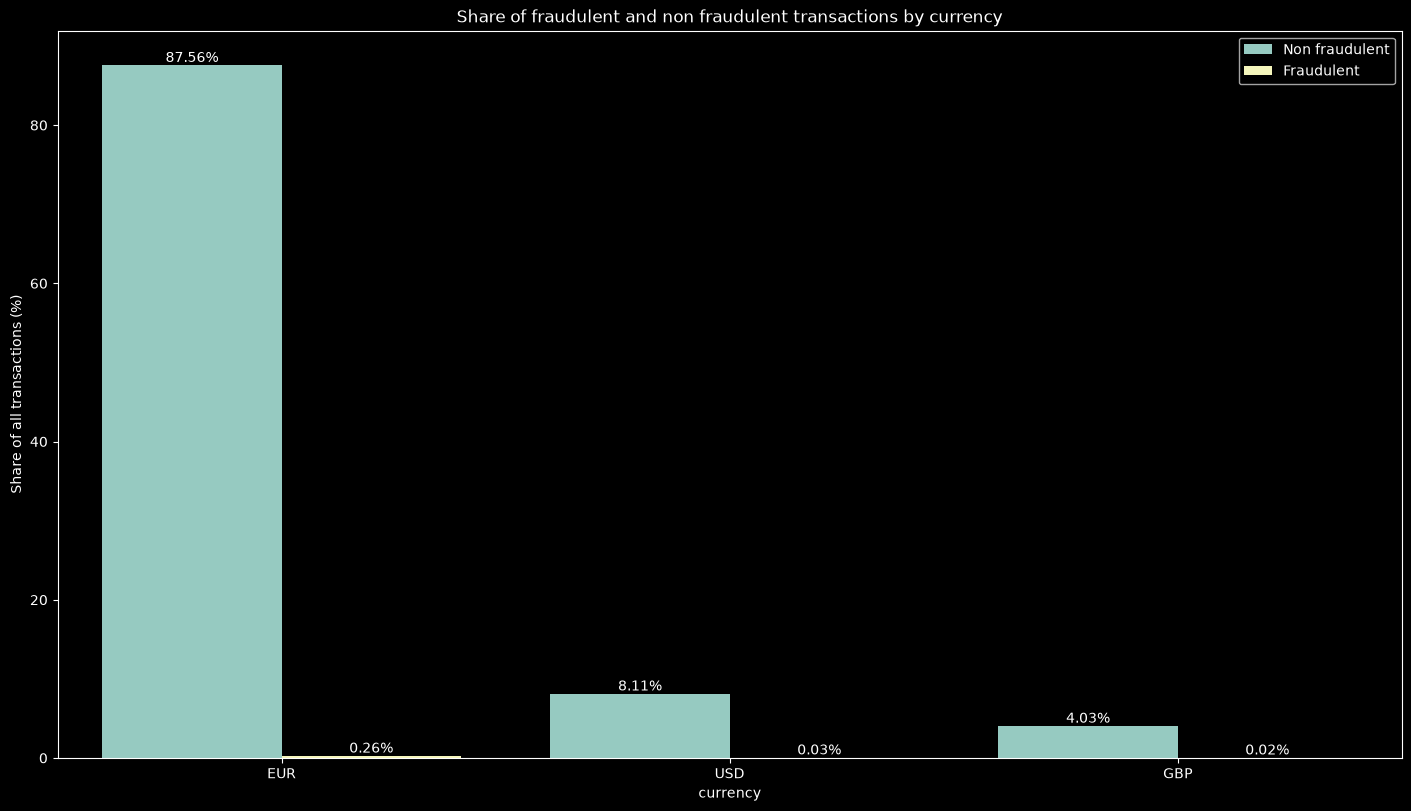

## Number of currency by fraud count

,number_of_frauds,number_of_currency
0,17,1
1,25,1
2,255,1


## Share of currency by fraud status

is_fraud,0,1,All
currency,,,
EUR,0.878218,0.858586,0.87816
GBP,0.040460,0.057239,0.04051
USD,0.081322,0.084175,0.08133


## Share of fraud by currency

is_fraud,0,1
currency,,
EUR,0.997096,0.002904
GBP,0.995804,0.004196
USD,0.996926,0.003074
All,0.997030,0.002970


In [26]:
analyze_categorical(
    df=df,
    col="currency",
    title="Share of fraudulent and non fraudulent transactions by currency",
    y_label="Share of all transactions (%)",
    legend_labels=FRAUD_LEGEND,
    index_column_name="number_of_currency",
    table_1_name="Number of currency by fraud count",
    table_2_name="Share of currency by fraud status",
    table_3_name="Share of fraud by currency",
    # is_bar_label=False,
)

### device_type

In [ ]:
analyze_categorical(
    df=df,
    col="device_type",
    title="Share of fraudulent and non fraudulent transactions by device_type",
    y_label="Share of all transactions (%)",
    legend_labels=FRAUD_LEGEND,
    index_column_name="number_of_device_type",
    table_1_name="Number of device type by fraud count",
    table_2_name="Share of device type by fraud status",
    table_3_name="Share of fraud by device type",
)

### entry_mode

In [ ]:
analyze_categorical(
    df=df,
    col="entry_mode",
    title="Share of fraudulent and non fraudulent transactions by entry mode",
    y_label="Share of all transactions (%)",
    legend_labels=FRAUD_LEGEND,
    index_column_name="number_of_entry_mode",
    table_1_name="Number of entry mode by fraud count",
    table_2_name="Share of entry mode by fraud status",
    table_3_name="Share of fraud by entry mode",
)

### channel

In [ ]:
analyze_categorical(
    df=df,
    col="channel",
    title="Share of fraudulent and non fraudulent transactions by channel",
    y_label="Share of all transactions (%)",
    legend_labels=FRAUD_LEGEND,
    index_column_name="number_of_channel",
    table_1_name="Number of channel by fraud count",
    table_2_name="Share of channel by fraud status",
    table_3_name="Share of fraud by channel",
)

### is_international

In [ ]:
analyze_categorical(
    df=df,
    col="is_international",
    title="Share of fraudulent and non fraudulent transactions by international type",
    y_label="Share of all transactions (%)",
    legend_labels=FRAUD_LEGEND,
    index_column_name="number_of_international_type",
    table_1_name="Number of international type by fraud count",
    table_2_name="Share of international type by fraud status",
    table_3_name="Share of fraud by international type",
)

## Multivariate analysis

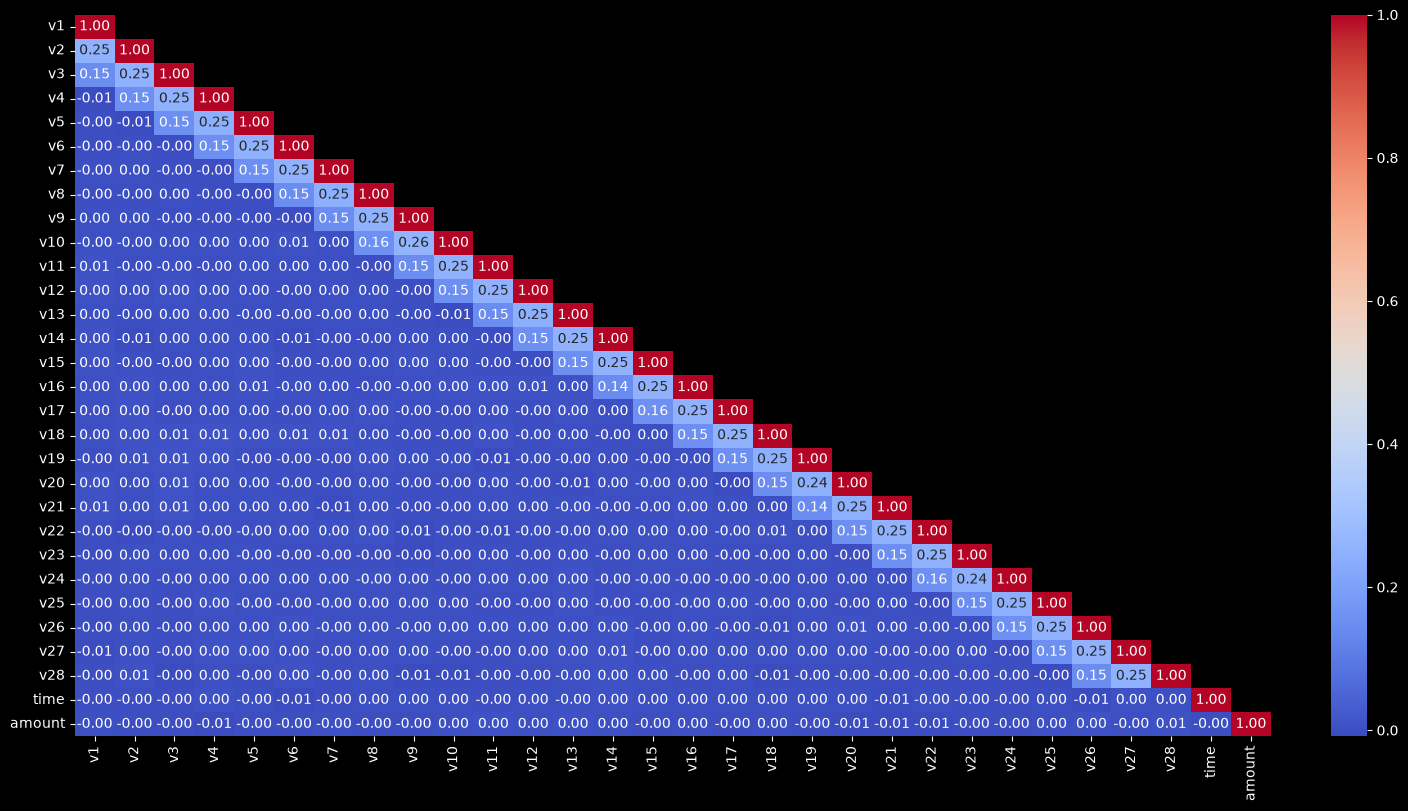

In [41]:
cols = [f"v{i}" for i in range(1, 29)]
cols.extend(["time", "amount"])
corr = df[cols].corr()

matrix = np.triu(corr)
np.fill_diagonal(matrix, False)
ax = sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", mask=matrix)

ax.tick_params("y", rotation=0)